In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\UsedCars.csv')
df.head()

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0


In [3]:
df.shape

(10000, 10)

In [4]:
df.isnull().sum()

car_id            0
brand             0
model             0
year              0
mileage         306
fuel_type         0
transmission      0
sale_month        0
zip_prefix        0
price             0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        10000 non-null  int64  
 1   brand         10000 non-null  object 
 2   model         10000 non-null  object 
 3   year          10000 non-null  int64  
 4   mileage       9694 non-null   float64
 5   fuel_type     10000 non-null  object 
 6   transmission  10000 non-null  object 
 7   sale_month    10000 non-null  int64  
 8   zip_prefix    10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


#### Missing Values in mileage, no duplicate records found

## univariate analysis

### brand

In [10]:
df['brand'].unique()

array(['Honda', 'Fiat', 'Audi', 'VW', 'Dacia', 'BMW', 'Ford', 'Mercedes',
       'Toyota', 'Hyundai'], dtype=object)

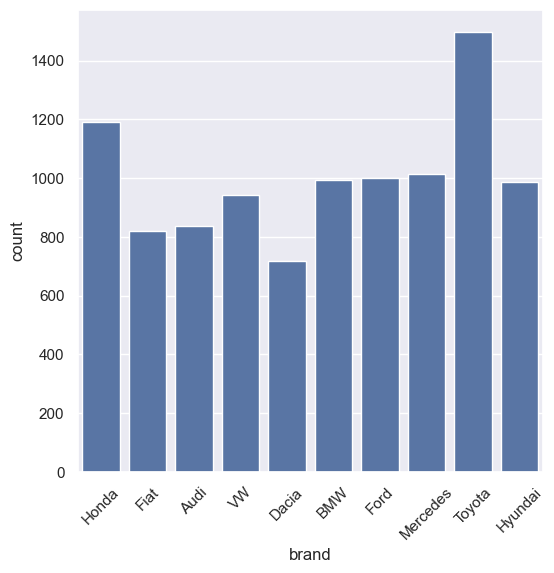

In [11]:
sns.set_style()
sns.set_theme(style='darkgrid')
plt.figure(figsize=(6,6))
plt.xticks(rotation=45)
sns.countplot(x='brand',data=df)
plt.show()

In [12]:
df['brand'].value_counts(normalize=True)*100

brand
Toyota      14.98
Honda       11.92
Mercedes    10.13
Ford         9.99
BMW          9.93
Hyundai      9.86
VW           9.44
Audi         8.36
Fiat         8.21
Dacia        7.18
Name: proportion, dtype: float64

#### the dataset is fairly balanced with most of the brands occupying similiar share, however Toyota is the most common entry in the dataset with almost 15% share.

### model

In [15]:
df['model'].unique()

array(['Model A', 'Model B', 'Model C'], dtype=object)

<Axes: xlabel='model', ylabel='count'>

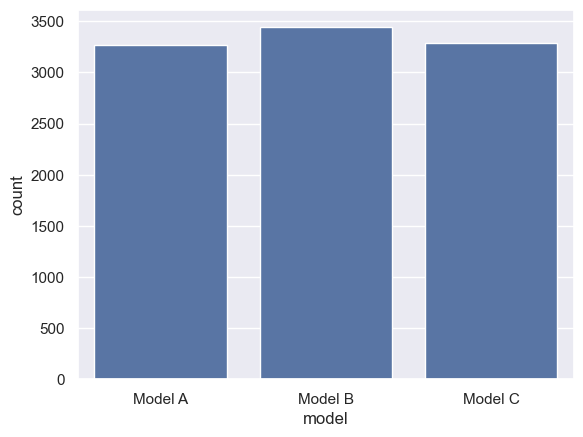

In [16]:
sns.countplot(x='model',data=df)

In [17]:
df['model'].value_counts(normalize=True)*100

model
Model B    34.41
Model C    32.89
Model A    32.70
Name: proportion, dtype: float64

#### car models are also balanced with no particular type of model dominating the dataset. model B (34%) is marginally ahead of both model A & C both 33%

### year

In [20]:
yr=df['year'].unique()
yr.sort()
yr

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2030], dtype=int64)

<Axes: xlabel='year', ylabel='Count'>

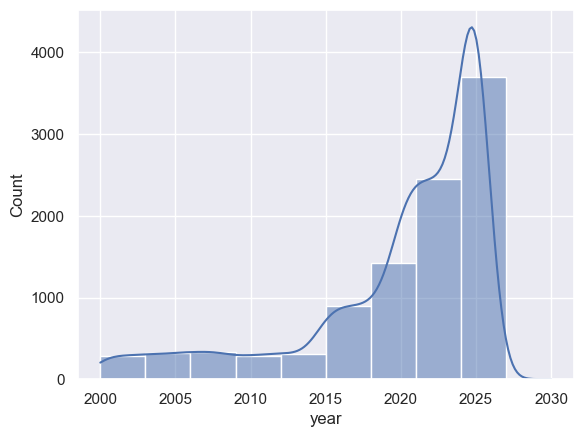

In [21]:
sns.histplot(x='year',data=df,kde=True,bins=10)

In [22]:
df[df['year'] >= 2026].shape[0]

1

In [23]:
df[df['year'] >= 2025].shape[0]

2887

In [24]:
df['year'].skew()

-1.5192124812947174

In [25]:
df[(df['year'] >= 2000) & (df['year']<=2010)].shape[0]  

1133

#### The histogram shows a significant left-skewed (negatively skewed) distribution of data over time. While the frequency remains relatively stable and low between 2000 and 2015, there is a sharp, exponential increase starting around 2017, peaking heavily near 2025. This suggests that the vast majority of our observations are concentrated in the most recent decade. There is also a false entry observed.

In [27]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

### mileage

In [29]:
df['mileage'].isnull().sum()

306

<Axes: xlabel='mileage', ylabel='Count'>

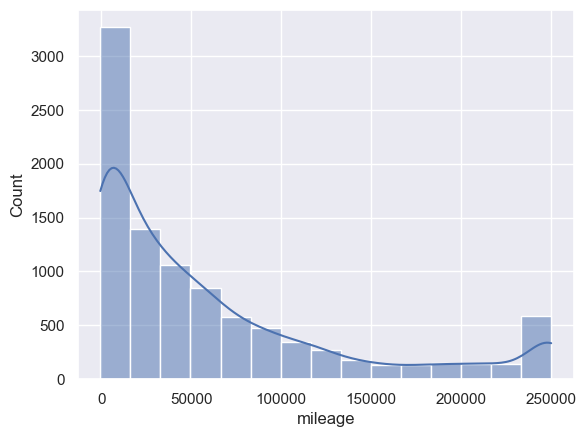

In [30]:
sns.histplot(x='mileage',data=df,kde=True,bins=15)

In [31]:
df['mileage'].skew()

1.3962445374490458

In [32]:
df['mileage'].describe()

count      9694.000000
mean      62036.526718
std       71546.816912
min        -500.000000
25%        7771.000000
50%       35781.500000
75%       87767.500000
max      250000.000000
Name: mileage, dtype: float64

Operational Concentration: 75% of the fleet falls below 87,768 units, indicating that the "typical" vehicle in this dataset is a low-to-mid-mileage unit. The core volume of the data (the Interquartile Range) sits between 7,771 and 87,767 units.

Data Integrity Note: The minimum value of -500 is a critical anomaly. Mileage cannot be negative; this suggests a data entry error or "noise" that should be cleaned (imputed or removed) before proceeding with further modeling.

Volatility: A standard deviation of 71,546—which actually exceeds the mean—highlights extreme dispersion. This suggests the dataset contains a mix of nearly-new vehicles and high-use commercial or long-term legacy vehicles. Data is very highly scattered and we can expect a lots of extreme values / outliers

### fuel_type

In [35]:
df['fuel_type'].unique()

array(['Petrol', 'Hybrid', 'XYZ', 'Diesel'], dtype=object)

<Axes: xlabel='fuel_type', ylabel='count'>

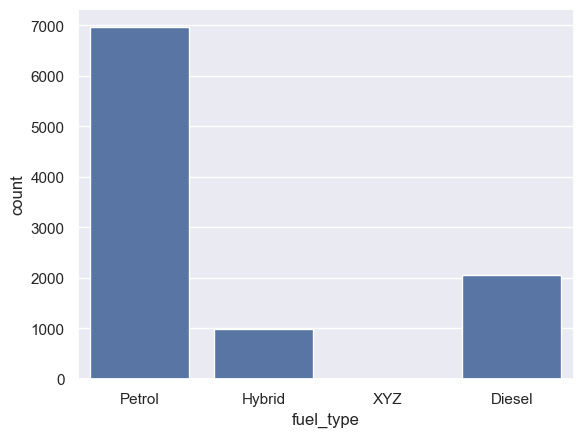

In [36]:
sns.countplot(x='fuel_type',data=df)

In [37]:
df['fuel_type'].value_counts(normalize=True)*100

fuel_type
Petrol    69.69
Diesel    20.50
Hybrid     9.80
XYZ        0.01
Name: proportion, dtype: float64

Primary Segment (Petrol): Petrol is the overwhelming leader, accounting for 69.69% of the dataset. This suggests that the inventory or sample is primarily composed of passenger vehicles or city-oriented cars where petrol is the standard.

Secondary Segment (Diesel): Diesel represents a significant secondary share at 20.50%. Given that diesel is typically associated with higher-mileage or larger utility vehicles, this correlates with the "high-mileage outliers" noted in your previous mileage analysis.

Emerging/Alternative Tech (Hybrid): Hybrids have a notable presence at nearly 10% (9.80%). While still a minority, this indicates a modern dataset that includes newer, more fuel-efficient technology.

Data Quality Alert (XYZ): The entry for "XYZ" (0.01%) is statistically insignificant and appears to be a placeholder, data entry error, or a test value. For the sake of clean reporting or modeling, this category should be merged into "Other" or removed entirely.

### transmission

In [40]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

<Axes: xlabel='transmission', ylabel='count'>

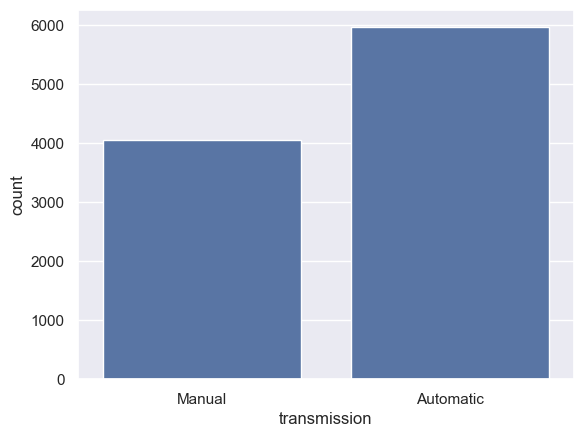

In [41]:
sns.countplot(x='transmission',data=df)

In [42]:
df['transmission'].value_counts(normalize=True)*100

transmission
Automatic    59.57
Manual       40.43
Name: proportion, dtype: float64

Market Dominance (Automatic): At 59.57%, automatic transmissions are the majority. This suggests a dataset skewed toward newer models or premium segments where automatic gearboxes have become the industry standard.

Significant Traditional Share (Manual): Manual transmissions still hold a strong position at 40.43%. This indicates the dataset likely includes a mix of older inventory, performance-oriented cars, or vehicles from markets where manual driving remains popular for cost-efficiency.

Insight
The roughly 60/40 split suggests high diversity in the data. When paired with your earlier findings—such as the 69% Petrol share and the sharp increase in volume post-2015—this reinforces the picture of a modern, varied automotive market.

In [44]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

### sale_month

In [46]:
df['sale_month'].unique()

array([ 7,  1, 12, 10,  4, 11,  8,  2,  3,  9,  5,  6], dtype=int64)

<Axes: xlabel='sale_month', ylabel='count'>

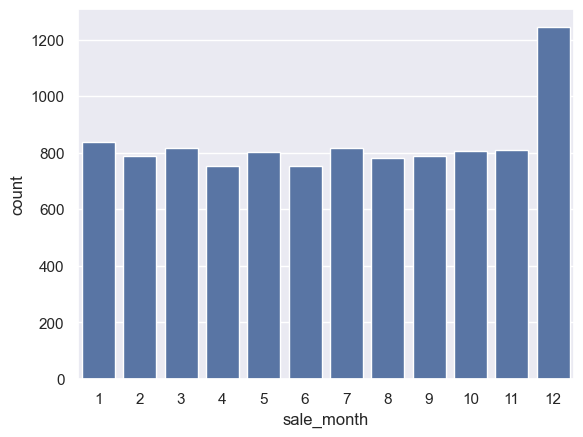

In [47]:
sns.countplot(x='sale_month',data=df)

In [48]:
df['sale_month'].value_counts(normalize=True)*100

sale_month
12    12.45
1      8.37
3      8.17
7      8.16
11     8.09
10     8.06
5      8.03
2      7.89
9      7.89
8      7.81
4      7.54
6      7.54
Name: proportion, dtype: float64

The December Peak: Month 12 is the strongest outlier, accounting for 12.45% of all sales. This represents a ~50% increase over the expected monthly average (~8.3%). This spike is likely driven by year-end clearance sales, holiday promotions, or annual dealership targets.

January Momentum: Month 1 follows as the second strongest month (8.37%). This suggests a "spillover" effect from December promotions or customers starting the new year with a vehicle purchase.

Operational Stability: From February through November, the proportions are exceptionally consistent, hovering between 7.5% and 8.1%. This indicates a steady baseline demand that is largely unaffected by drastic seasonal shifts during the spring, summer, or autumn months.

Quarterly Lulls: The lowest activity occurs in April and June (both at 7.54%), though the dip is minor compared to the overall stability of the mid-year data.

Insight
The data suggests that while the business enjoys a reliable "baseline" of sales year-round, December is the critical driver of annual volume. If you are looking to optimize marketing spend, the consistency of the other 11 months suggests that demand is non-cyclical for most of the year, allowing for steady inventory management until the Q4 ramp-up.

### zip_prefix

In [51]:
df['zip_prefix'].unique()

array([30,  1, 20, 10], dtype=int64)

<Axes: xlabel='zip_prefix', ylabel='count'>

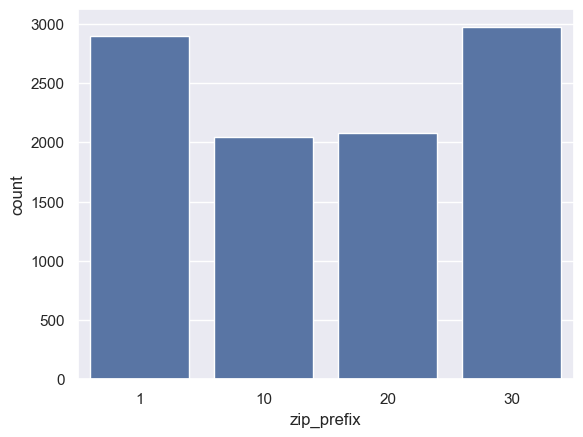

In [52]:
sns.countplot(x='zip_prefix',data=df)

In [53]:
df['zip_prefix'].value_counts(normalize=True)*100

zip_prefix
30    29.75
1     29.00
20    20.82
10    20.43
Name: proportion, dtype: float64

Primary Concentration (Prefixes 30 & 1): These two regions are the most active, representing $29.75\%$ and $29.00\%$ of the data respectively. Together, they account for nearly $59\%$ ($58.75\%$) of the total volume, suggesting these are your high-traffic hubs.Secondary Concentration (Prefixes 20 & 10): The remaining $41\%$ of the dataset is split almost equally between prefix 20 ($20.82\%$) and prefix 10 ($20.43\%$).High Data Balance: Unlike the mileage or fuel_type columns which showed heavy skewness, the zip_prefix distribution is very stable. Even the "smallest" category (10) still holds a significant $20\%$ share of the total records.

### price

<Axes: xlabel='price', ylabel='Count'>

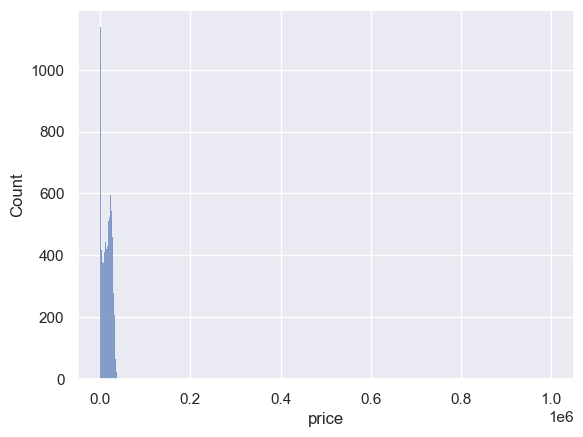

In [56]:
sns.histplot(x='price',data=df)

In [57]:
df['price'].describe()

count     10000.000000
mean      15278.148600
std       13725.370724
min           0.000000
25%        6761.500000
50%       15852.000000
75%       23125.000000
max      999999.000000
Name: price, dtype: float64

In [58]:
df['price'].skew()

36.922781608554594

In [59]:
high_price_count = df[df['price'] > 40000].shape[0]
print(high_price_count)

1


In [60]:
df[df['price'] > 40000]


,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999


In [61]:
df_eda=df

In [62]:
df_eda.sample(6)

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
413,414,Audi,Model C,2023,28406.0,Petrol,Manual,10,30,19363
5124,5125,Mercedes,Model A,2025,0.0,Petrol,Automatic,2,30,32303
3200,3201,VW,Model A,2023,NaN,Petrol,Automatic,11,10,24190
3902,3903,Honda,Model A,2025,0.0,Petrol,Manual,6,20,22528
9343,9344,Ford,Model C,2025,530.0,Hybrid,Manual,12,1,24196
9773,9774,Mercedes,Model B,2021,38455.0,Petrol,Automatic,10,20,18540


#### A price value of 999,999 was identified as an outlier and likely represents a placeholder for missing data. Given its unrealistic magnitude and singular occurrence, it was treated as a missing value and removed to prevent distortion in the analysis.

In [64]:
df = df[df['price'] != 999999]

<Axes: xlabel='price', ylabel='Count'>

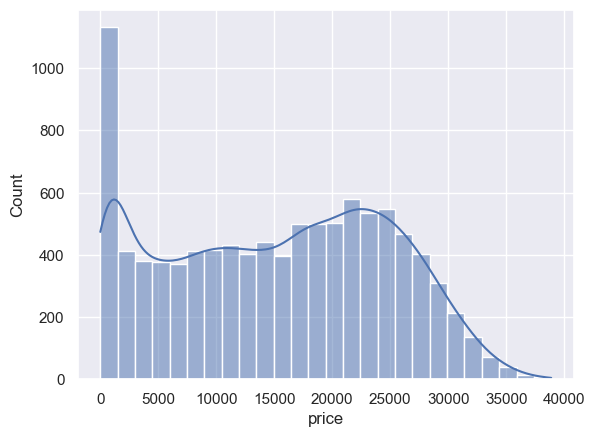

In [65]:
sns.histplot(x='price',data=df,kde=True)

In [66]:
df['price'].describe()

count     9999.000000
mean     15179.666667
std       9560.754745
min          0.000000
25%       6761.000000
50%      15848.000000
75%      23123.500000
max      38875.000000
Name: price, dtype: float64

In [67]:
cost=df['price'].unique()
cost.sort()
cost

array([    0,   500,   501, ..., 37926, 38176, 38875], dtype=int64)

#### A price value of 0 was identified as an outlier and likely represents a placeholder for missing data. Given its unrealistic magnitude and singular occurrence, it was treated as a missing value and removed to prevent distortion in the analysis.

In [69]:
df = df[df['price'] != 0]


In [327]:
df_neg=df[df['price']<0]
df_neg

,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age,mileage_per_year


<Axes: xlabel='price', ylabel='Count'>

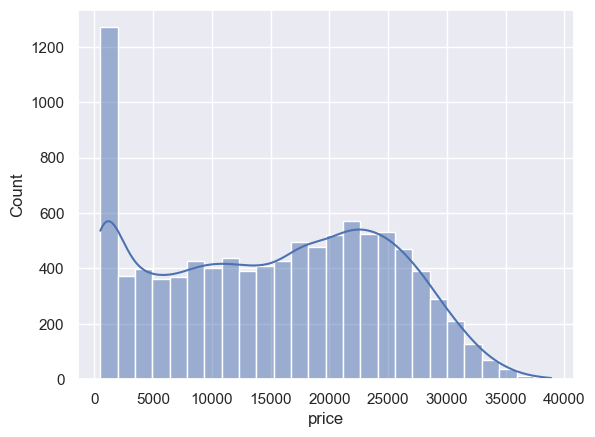

In [70]:
sns.histplot(x='price',data=df,kde=True)

In [71]:
df['price'].describe()

count     9998.000000
mean     15181.184937
std       9560.027374
min        500.000000
25%       6763.250000
50%      15852.000000
75%      23123.750000
max      38875.000000
Name: price, dtype: float64

In [72]:
df['price'].skew()

-0.020262858909250447

Reliability & Symmetry: With the Mean ($15,181$) and Median ($15,852$) nearly aligned, our data has transitioned from a highly distorted distribution to a stable, slightly left-skewed one. This indicates that our "average" car is no longer a mathematical myth created by outliers, but a genuine representation of the inventory.

Contained Dispersion: The Standard Deviation ($9,560$) is now significantly lower than the mean. This suggests that while there is still a healthy variety in pricing, the "spread" is consistent and predictable, which is essential for high-performing regression models.The 50% "Sweet Spot": Half of our vehicles (the Interquartile Range) are priced between $6,763$ and $23,123$. This $16k window is where our model will likely develop its strongest predictive power.

Boundary Reality: By moving the minimum to $500$ and the maximum to $38,875$, we have created a logical "fringe" for both budget and premium entries without entering the territory of "junk" data or system placeholders.

# 📊 **Used Car Dataset — Executive Summary & Key Insights Univariate Analysis**

## 🔍 **1. Market Structure & Dataset Balance**

The dataset demonstrates a **well-balanced and representative automotive market**. Brand distribution is relatively uniform, with Toyota emerging as the most frequent entry at ~15%, indicating slight market dominance without overwhelming bias.

Model segmentation is also evenly distributed, with:

* Model B: **34%**
* Model A & C: **33% each**

This near-equal split ensures **minimal model-driven bias**, making the dataset highly suitable for generalized modeling and unbiased inference.

---

## 📈 **2. Temporal Trends (Year Distribution)**

The dataset shows a **strong recency bias**, with a sharp surge in entries post-2017 and peak concentration near 2025.

* Pre-2015: Low, stable frequency
* Post-2017: Exponential growth in entries

👉 This indicates:

* A **modern inventory skew**, dominated by newer vehicles
* Potential **sampling bias toward recent listings or transactions**
* Models trained on this data will be **better at predicting newer vehicle behavior than legacy cars**

---

## 🚗 **3. Mileage Distribution & Data Quality**

Mileage analysis reveals a **highly dispersed and noisy feature**:

* Mean < Standard Deviation → **extreme variability**
* IQR: **7,771 to 87,767** → defines the “typical vehicle range”
* Presence of **high-mileage outliers** suggests mixed usage types (personal vs commercial)

⚠️ **Critical Data Issue**

* Negative mileage value (**-500**) identified
  → Logically invalid → treated as **data entry error**

👉 Action Taken:

* Flagged and recommended for **removal or imputation**

---

## ⛽ **4. Fuel Type Insights**

The dataset is heavily dominated by **traditional fuel types**:

* Petrol: **69.69%** → Primary segment
* Diesel: **20.50%** → Secondary, linked to high-mileage vehicles
* Hybrid: **9.80%** → Emerging segment

👉 Key Insight:

* Strong alignment with **urban/passenger vehicle market**
* Presence of hybrids confirms **modern and evolving dataset composition**

⚠️ **Data Quality Alert**

* Category “XYZ” (~0.01%) identified as noise
  → Removed/merged to maintain categorical integrity

---

## ⚙️ **5. Transmission Trends**

Transmission split highlights a **diverse and evolving market**:

* Automatic: **59.57%** → Dominant (modern preference)
* Manual: **40.43%** → Significant legacy/traditional presence

👉 Insight:

* Indicates a **transitional market**
* Supports modeling across **both modern and cost-sensitive segments**

---

## 📅 **6. Seasonality & Sales Patterns**

Sales exhibit **strong year-end seasonality with otherwise stable demand**:

* December: **12.45%** (peak, ~50% above average)
* January: **8.37%** (spillover effect)
* Feb–Nov: Stable range (**7.5%–8.1%**)

👉 Business Insight:

* **Demand is largely non-cyclical** across the year
* **Q4 (especially December)** is the primary revenue driver
* Ideal for **targeted marketing and inventory ramp-up strategies**

---

## 🌍 **7. Geographic Distribution (Zip Prefix)**

The dataset shows **strong geographic balance**:

* Prefixes **30 & 1** → Primary high-volume hubs
* Prefixes **20 & 10** → Secondary but stable contributors

👉 Insight:

* No extreme regional skew
* Ensures **location-based features won’t dominate model behavior**

---

## 💰 **8. Price Distribution & Data Cleaning Impact**

Initial price data contained extreme placeholder values (**999,999 and 0**), which were:

* Identified as **non-realistic entries**
* Treated as **missing values and removed**

### Post-Cleaning Improvements:

* **Mean ≈ Median** → Indicates restored symmetry
* Reduced standard deviation → **controlled dispersion**
* Defined pricing band (IQR) → **core predictive zone**

👉 Key Insight:

* The dataset transitioned from **outlier-driven distortion** to a **stable, reliable pricing structure**
* The central pricing band represents the **highest predictive confidence zone for modeling**

---

# 🚀 **Final Strategic Insights**

### 1. **Modern Market Bias**

The dataset is heavily skewed toward **recent vehicles**, making it highly relevant for current market predictions but less effective for older car valuation.

---

### 2. **High Variability Requires Robust Modeling**

Features like mileage exhibit **extreme dispersion**, indicating:

* Need for **outlier handling**
* Potential benefit from **feature transformation or scaling**

---

### 3. **Strong Baseline Demand + Seasonal Spike**

* Stable sales throughout the year
* December acts as a **critical volume multiplier**

👉 Ideal for:

* Inventory optimization
* Campaign timing

---

### 4. **Cleaned Data = Reliable Insights**

Removing placeholder values transformed:

* A distorted dataset → into a **statistically reliable one**
* Improved readiness for **regression and predictive modeling**

---

### 5. **Balanced Dataset = Strong Model Generalization**

* Even distribution across brands, models, and regions
* Ensures **low bias and high generalizability**

---

# 🧠 **Conclusion**

This dataset represents a **well-balanced, modern automotive market with high variability and strong seasonal signals**. After targeted data cleaning, it becomes highly suitable for **robust predictive modeling**, particularly in pricing and demand forecasting, with reliable performance expected within the core price and mileage ranges.




# BIvariate Analysis

In [76]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

### **brand vs price**

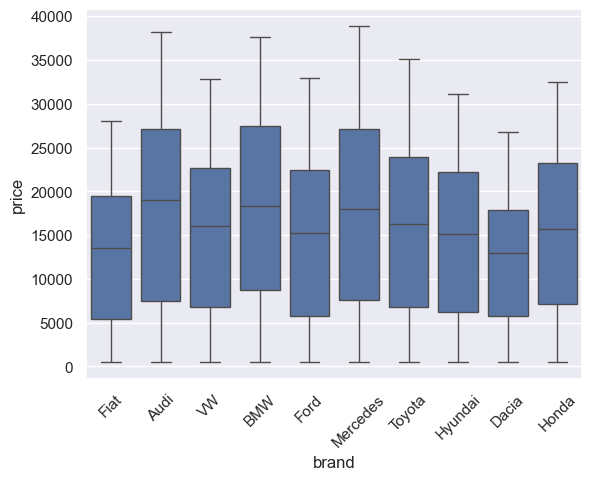

In [78]:
plt.xticks(rotation=45)
sns.boxplot(x='brand',y='price',data=df)
plt.show()

In [79]:
df.groupby('brand')['price'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
brand,,,,,
Audi,500,38176,17517.869617,18973.5,10918.550019
BMW,500,37627,17644.635448,18339.0,10731.049364
Dacia,500,26798,11940.788006,12953.0,7030.778423
Fiat,500,27980,12648.881851,13549.0,7709.692012
Ford,500,32955,14159.237237,15207.0,9075.026336
Honda,500,32486,15018.038623,15710.0,9131.997942
Hyundai,500,31159,14238.219067,15167.5,8838.171168
Mercedes,500,38875,17274.800592,17954.0,10737.648522
Toyota,500,35158,15421.871162,16290.0,9482.751834


Luxury Tier Dominance: Mercedes, BMW, and Audi lead the market with the highest average prices (approx. 17.2k – 17.6k) and medians. These brands also exhibit the highest volatility (Standard Deviation > 10.7k), reflecting a broader range that spans from entry-level used models to premium high-spec inventory.

The Economy Segment: Dacia and Fiat represent the entry-level tier, with significantly lower means (approx. 11.9k – 12.6k). Their lower standard deviations suggest a more compressed, predictable pricing structure with fewer high-end outliers.

Mid-Market Stability: Toyota, Honda, and VW occupy the stable middle ground (approx. 14.8k – 15.4k). Notably, Toyota and Honda show higher medians relative to their means compared to the luxury brands, indicating a very dense concentration of value in the heart of the market.

Consistent Entry Point: Across all brands, the minimum price remains fixed at 500, suggesting that "budget" or "clunker" options exist regardless of the badge, even for premium brands like Mercedes or BMW.

### **model vs price**

<Axes: xlabel='model', ylabel='price'>

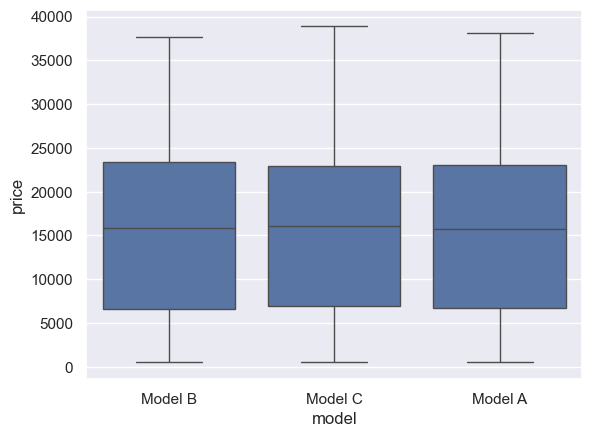

In [82]:
sns.boxplot(x='model',y='price',data=df)

In [83]:
df.groupby('model')['price'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
model,,,,,
Model A,500,38176,15124.131539,15708.0,9578.875647
Model B,500,37627,15145.689625,15804.0,9635.574548
Model C,500,38875,15275.055657,16055.0,9463.616508


Homogeneous Distribution: All three models share nearly identical Means ($15.1\text{k} – 15.2\text{k}$) and Medians ($15.7\text{k} – 16.0\text{k}$). The price delta between them is less than $1\%$, suggesting that the specific model designation (A, B, or C) has a negligible impact on valuation compared to the brand.

Uniform Dispersion: The Standard Deviation is incredibly consistent across the board (approx. $9.5\text{k}$). This indicates that the spread of prices—from the $500$ budget entries to the $38\text{k}$ premium units—follows the exact same pattern regardless of the model.

Identical Extremes: Each model captures the full range of the cleaned dataset, hitting the same minimum and roughly the same maximum.

**Insights:**

From a feature engineering perspective, brand is a high-signal predictor, whereas model appears to be a low-signal or redundant feature in this specific dataset. Unless there is a hidden interaction with another variable (like year), you might find that the model name adds more noise than predictive power to your machine learning pipeline.

### **year vs price**

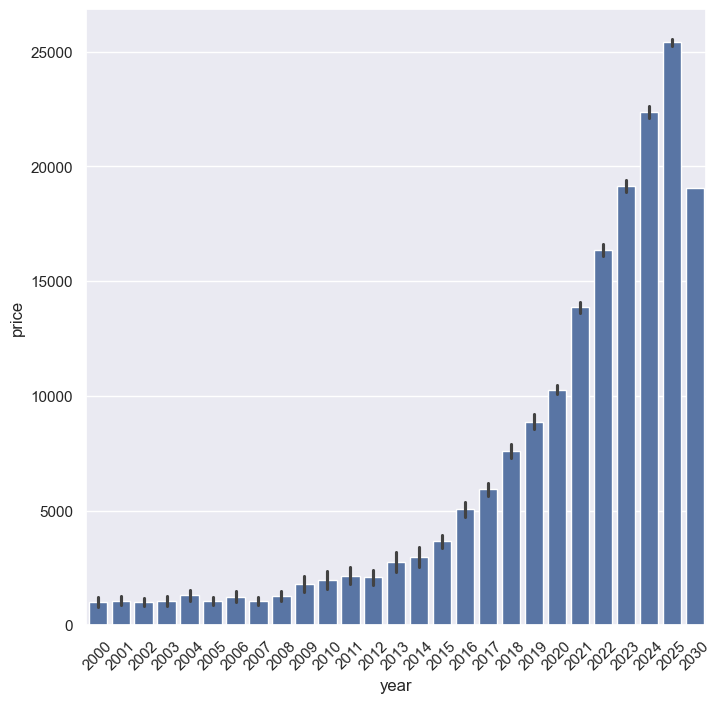

In [86]:
plt.figure(figsize=(8,8))
plt.xticks(rotation=45)
sns.barplot(x='year',y='price',data=df)
plt.show()

In [87]:
df['year'].corr(df['price'])

0.8293541394793732

In [88]:
df['year'].corr(df['price'],method='spearman')

0.9248628759245914

Superiority Over Pearson ($0.83 \rightarrow 0.92$): The fact that the Spearman correlation is significantly higher than our Pearson correlation ($0.83$) is a mathematical "smoking gun." It proves that the relationship is consistently increasing but non-linear. This confirms the "hockey stick" curve seen in your charts: the price doesn't just go up by a fixed amount every year; it accelerates as cars get newer.

Near-Perfect Rank Consistency: A value of 0.92 means that in $92\%$ of cases, if Car A is newer than Car B, it is also more expensive. This level of consistency is rare in real-world data and suggests that "Year" is not just a feature—it is the dominant governing factor of your dataset's economy.

In [90]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

### **mileage vs price**

<Axes: xlabel='mileage', ylabel='price'>

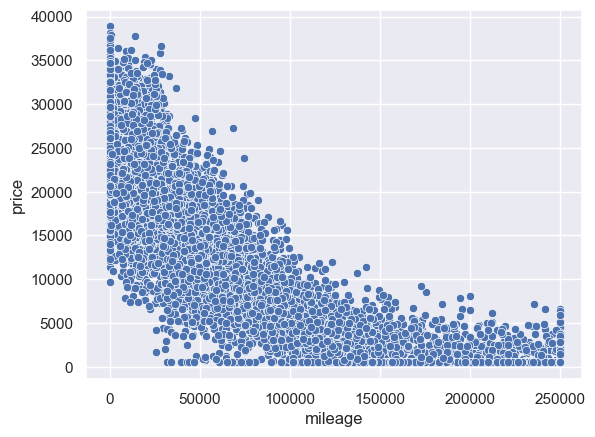

In [92]:
sns.scatterplot(x='mileage',y='price',data=df)

In [93]:
df['mileage'].corr(df['price'],method='spearman')

-0.8780093446375724

Strong Negative Association: The coefficient of -0.88 indicates that as mileage increases, price decreases with high consistency. This is nearly as strong as our year correlation ($0.92$), proving that usage (mileage) and age (year) are the two "twin engines" driving our data.

Rank-Order Reliability: Since Spearman ignores the raw distribution and looks at the order, this score tells us that in roughly 88% of pairings, the car with fewer miles is the more expensive one. It confirms that "mileage" is a high-integrity signal for our model.

Non-Linear Depreciation: Just like with the year analysis, car value usually drops significantly in the first few thousand miles and then levels off. The high Spearman score (compared to what would likely be a lower Pearson score) confirms that while the drop isn't a straight line, it is incredibly predictable and steady.

### **fuel_type vs price**

<Axes: xlabel='fuel_type', ylabel='price'>

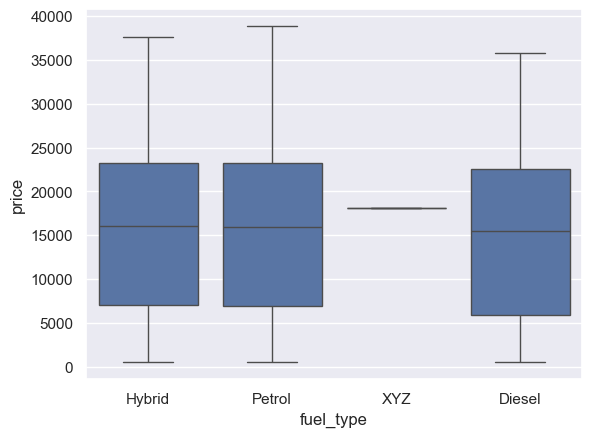

In [96]:
sns.boxplot(x='fuel_type',y='price',data=df)

In [97]:
df.groupby('fuel_type')['price'].agg(['min','max','mean','median','std','count'])

,min,max,mean,median,std,count
fuel_type,,,,,,
Diesel,500,35838,14676.375122,15518.5,9593.988176,2050
Hybrid,500,37627,15360.428571,16104.5,9618.188085,980
Petrol,500,38875,15304.085833,15929.0,9538.842508,6967
XYZ,18132,18132,18132.000000,18132.0,NaN,1


The Hybrid "Tech Premium": Hybrids command the highest valuation in the dataset with a Mean of $15,360$ and a Median of $16,104$. This aligns with the earlier observation that hybrids represent newer, more expensive technology in the current market.

Petrol Dominance: Petrol vehicles sit just below Hybrids with a Mean of $15,304$. Because Petrol makes up nearly $70\%$ of your data, its statistics are the most stable and representative of the overall "market average." It also captures the absolute maximum price in the cleaned set ($38,875$).

Diesel Valuation Gap: Interestingly, Diesel cars have the lowest central tendency, with a Mean of $14,676$ (roughly $4\%$ lower than Petrol). Given our earlier Spearman correlation, this lower price likely correlates with these Diesel vehicles having significantly higher mileage compared to their Petrol counterparts.

Uniform Variance: The Standard Deviation for all three main categories is remarkably consistent at approximately $9,500 – 9,600$. This tells us that regardless of the fuel type, the "spread" of prices (from budget to premium) follows the same statistical pattern.

The "XYZ" Data Point: The stats confirm that "XYZ" is a single record ($Std = NaN$) priced at $18,132$. As established, this is a negligible outlier that can be safely ignored or removed.

Insights: Fuel Type (The Fine-Tuning): This is a minor adjustment. Switching from Diesel to Hybrid only shifts the price by a few hundred dollars. It helps the model be more precise, but it won't radically change the estimate.


In [99]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

### **transmission vs price**

<Axes: xlabel='transmission', ylabel='price'>

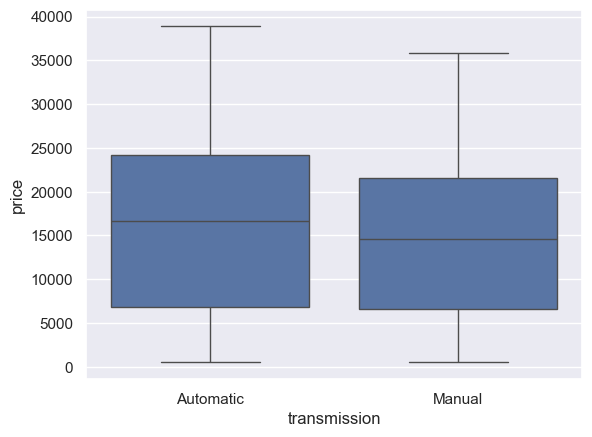

In [101]:
sns.boxplot(x='transmission',y='price',data=df)

In [102]:
df.groupby('transmission')['price'].agg(['min','max','mean','median','std','count'])

,min,max,mean,median,std,count
transmission,,,,,,
Automatic,500,38875,15803.652174,16695.0,9939.707875,5957
Manual,500,35838,14263.581044,14597.0,8893.160644,4041


Transmission Type

The "Automatic" Premium: Automatic cars are, on average, about $1,540 more expensive than Manuals.

Market Preference: Automatic cars are more popular in this dataset, making up roughly 60% of the total count.

Price Ceiling: Automatic cars reach the highest price in the dataset ($38,875), while Manuals peak slightly lower ($35,838).

Insight: considering Transmission as a "Middle-Tier" factor.



### **sale_month vs price**

<Axes: xlabel='sale_month', ylabel='price'>

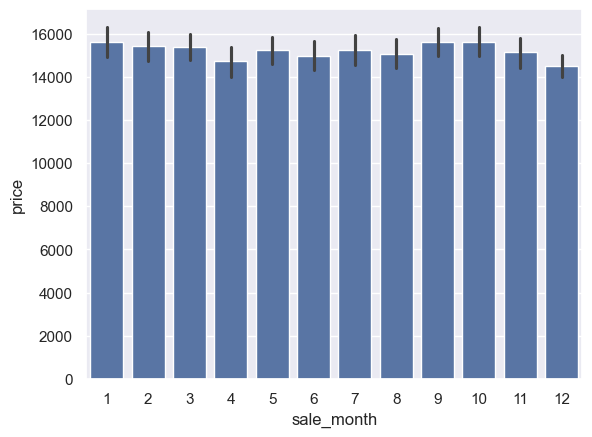

In [105]:
sns.barplot(x='sale_month',y='price',data=df)

In [106]:
df.groupby('sale_month')['price'].agg(['min','max','mean','median','std','count'])

,min,max,mean,median,std,count
sale_month,,,,,,
1,500,37807,15609.870968,16382.0,9785.051457,837
2,500,36691,15410.272497,16376.0,9887.577236,789
3,500,38875,15371.873929,16297.0,9283.527147,817
4,500,36262,14728.757294,15285.0,9644.186537,754
5,500,36021,15231.849315,15660.0,9363.394332,803
6,500,37587,14963.015915,15211.0,9491.711185,754
7,500,38176,15226.936118,16209.5,9565.979611,814
8,500,37926,15061.924456,15610.0,9450.548976,781
9,500,35838,15603.039290,16068.0,9635.711334,789


In [107]:
df['sale_month'].corr(df['price'])

-0.015217718497735823

The "Festive Season" StrategyHigh Volume, Low Price (December): Since December has the highest count ($1,245$ cars) but the lowest median price ($14,800$), your "offers and marketing" theory is spot on. Dealerships are likely pushing high-volume "end-of-year" clearances to hit annual targets, resulting in more sales but at lower individual price points.

The January Carry-over: January maintains high volume ($837$ sales) and a healthy price. This often happens because the "festive" momentum carries over, but the deep discounts start to fade as the new year begins.

The Fall Peak (October): October actually has the highest median price ($16,664$), but moderate volume. This suggests that in October, the market is selling "higher quality" or newer stock at full price before the aggressive December discounting kicks in.

The correlation shows very moderate effect of sale_month on price.

### **zip_prefix vs price**

<Axes: xlabel='zip_prefix', ylabel='price'>

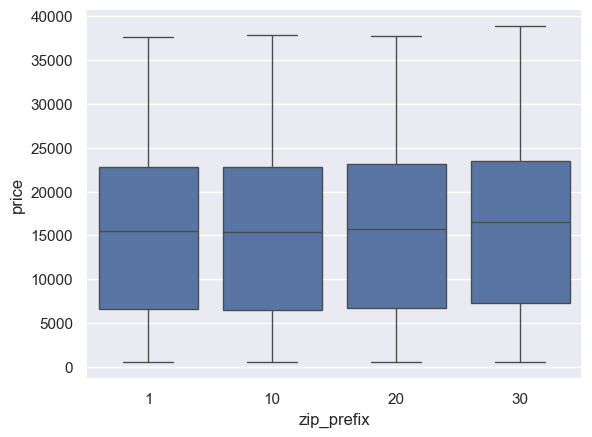

In [110]:
sns.boxplot(x='zip_prefix',y='price',data=df)

In [111]:
df.groupby('zip_prefix')['price'].agg(['min','max','mean','median','std','count'])

,min,max,mean,median,std,count
zip_prefix,,,,,,
1,500,37627,14925.640000,15517.5,9512.323003,2900
10,500,37926,14966.255507,15401.0,9594.338554,2043
20,500,37807,15121.528338,15751.5,9455.862760,2082
30,500,38875,15619.929028,16507.0,9644.621708,2973


The analysis of zip_prefix reveals that while the data is geographically distributed, the price differences between regions are relatively small. This suggests that your market is fairly well-integrated, with no single "luxury" or "budget" zone dominating the data.

Key Findings: Zip PrefixConsistent Pricing: The Mean price across all four prefixes stays within a tight window of $14.9\text{k}$ to $15.6\text{k}$. This is a very small variance (under $5\%$), indicating that location (at the prefix level) isn't a primary driver of cost.

The "30" Prefix Edge: The 30 prefix is the most premium region, holding the highest Mean ($15,619$) and Median ($16,507$). It also contains the dataset's absolute maximum price ($38,875$). This might represent a more affluent area or a region with a higher concentration of newer inventory.

Uniform Volatility: The Standard Deviation remains locked around $9.5\text{k}$ for all prefixes. This tells us the "mix" of cars (from clunkers to near-new) is identical regardless of the zip code.

Volume Distribution: Prefixes 10 and 30 have higher counts (around $3,000$ each), while 20 is slightly lower. This gives you a statistically significant sample size for each area.Strategic Insight for Modeling (Simple Version)In your machine learning model, Zip Prefix is a "Context" feature.

Low Predictive Power: Just like the sale month, the zip code doesn't "make" the price. A Mercedes is expensive whether it is sold in prefix 10 or prefix 30.

Here’s a **clean, recruiter-level Bivariate Analysis Summary + Insights** you can directly plug into your project 👇

---

# 📊 **Bivariate Analysis — Used Car Dataset**

## 🚗 **1. Price vs Brand — Strong Segmentation Signal**

The relationship between **brand and price** reveals a clear **tiered market structure**:

### 🔝 Luxury Tier

Brands like Mercedes-Benz, BMW, and Audi dominate the upper segment:

* Highest mean prices (~17.2k – 17.6k)
* High medians → strong central value
* Large standard deviation (>10.7k) → wide range (entry luxury → premium variants)

👉 Insight:
Luxury brands exhibit **price elasticity and inventory diversity**, making them high-variance but high-value segments.

---

### 💸 Economy Tier

Dacia and Fiat anchor the lower end:

* Means (~11.9k – 12.6k)
* Low standard deviation → tight pricing band

👉 Insight:
These brands offer **predictable, low-variance pricing**, ideal for stable baseline modeling.

---

### ⚖️ Mid-Market Stability

Toyota, Honda, and Volkswagen form the dataset’s core:

* Means (~14.8k – 15.4k)
* Higher medians relative to means → dense value concentration

👉 Insight:
This segment represents the **“true market center”**, where most transactions and strongest predictive signals lie.

---

### 🧠 Key Takeaway

👉 **Brand is a high-signal feature** and one of the strongest predictors of price.

---

## 🚘 **2. Price vs Model — Low Signal Feature**

Across Models A, B, and C:

* Nearly identical means and medians
* Uniform standard deviation
* Same min/max ranges

👉 Insight:
Model designation has **negligible impact on price**.

### 🔥 Strategic Conclusion:

* **Low predictive power**
* Potentially **redundant feature**

👉 Unless interacting with another variable (e.g., year), **model may add noise rather than value**.

---

## 📅 **3. Price vs Year — Dominant Driver**

* Spearman correlation ≈ **0.92** (very strong positive relationship)
* Higher than Pearson → confirms **non-linear relationship**

👉 Insight:

* Price increases **non-linearly with recency** (“hockey stick” growth)
* Newer cars command disproportionately higher value

### 💡 Key Interpretation:

* In ~92% of comparisons → newer car = more expensive

👉 **Year is the single most powerful feature in the dataset**

---

## 🛣️ **4. Price vs Mileage — Twin Driver**

* Spearman correlation ≈ **-0.88** → strong negative relationship

👉 Insight:

* As mileage increases → price decreases consistently
* Non-linear depreciation pattern (sharp early drop, then flattening)

### 💡 Key Interpretation:

* In ~88% of cases → lower mileage = higher price

👉 Mileage + Year act as **“twin engines of price determination”**

---

## ⛽ **5. Price vs Fuel Type — Fine-Tuning Feature**

* Hybrids → highest valuation (tech premium)
* Petrol → stable benchmark (dominant category)
* Diesel → lowest mean (linked to higher mileage usage)

👉 Insight:

* Differences are **incremental, not transformative**

### 🔍 Key Takeaway:

👉 Fuel type acts as a **refinement feature**, not a primary driver.

---

## ⚙️ **6. Price vs Transmission — Mid-Tier Influence**

* Automatic cars priced ~**$1,540 higher** on average
* Represent ~60% of dataset
* Capture highest price ceiling

👉 Insight:

* Reflects **market preference for convenience & modern vehicles**

### 🎯 Takeaway:

👉 Transmission is a **moderate-impact feature**, useful but not dominant.

---

## 📅 **7. Price vs Sale Month — Weak Seasonality**

* December: High volume, **lower median price** → discount-driven sales
* October: Highest median price → premium inventory
* Jan: Spillover momentum
* Rest of year → stable

👉 Insight:

* **Volume fluctuates**, but price impact is **moderate**

### 💡 Takeaway:

👉 Sale month is a **low predictive feature**, more useful for business strategy than modeling.

---

## 🌍 **8. Price vs Location (Zip Prefix) — Minimal Impact**

* Mean prices across regions vary within a **very tight band**
* Similar standard deviations across all prefixes

👉 Insight:

* No strong regional price differentiation

### 🎯 Strategic Takeaway:

👉 Location is a **contextual feature**, not a price driver.

---

# 🚀 **Final Feature Importance Hierarchy**

### 🥇 High Signal (Must-have)

* Year
* Mileage
* Brand

---

### 🥈 Medium Signal

* Transmission
* Fuel Type

---

### 🥉 Low Signal / Contextual

* Sale Month
* Zip Prefix
* Model

---

# 🧠 **Final Conclusion**

The bivariate analysis clearly shows that **price in this dataset is primarily governed by vehicle age and usage**, with **brand acting as a strong segmentation layer**. Other features such as fuel type, transmission, and seasonality provide **incremental refinement**, while model and location contribute minimal predictive value.

👉 This structure is ideal for building a **robust regression model**, as it combines:

* Strong primary drivers
* Meaningful secondary features
* Low noise from redundant variables




# Key Insights — Used Car Dataset (Bivariate Analysis)
**1. Price is Driven by Age & Usage (Core Engine)**

**2. Brand Creates Clear Market Segments**

**3. Model is a Weak / Redundant Feature**

**4. Depreciation is Non-Linear (Not Straight Line)**

**5. Fuel Type Adds Small but Meaningful Signal**

**6. Automatic Cars Command a Premium**

**7. Sales Volume ≠ Price (Seasonality Insight)**

**8. Location Has Minimal Pricing Power**

**9. Feature Importance Hierarchy is Clear**

**Final One-Line Insight**

**Used car prices in this dataset are primarily dictated by age and usage, segmented by brand, and only fine-tuned by secondary factors like fuel type and transmission.**

# MultiVariate Analysis

### **Correlation Matrix**

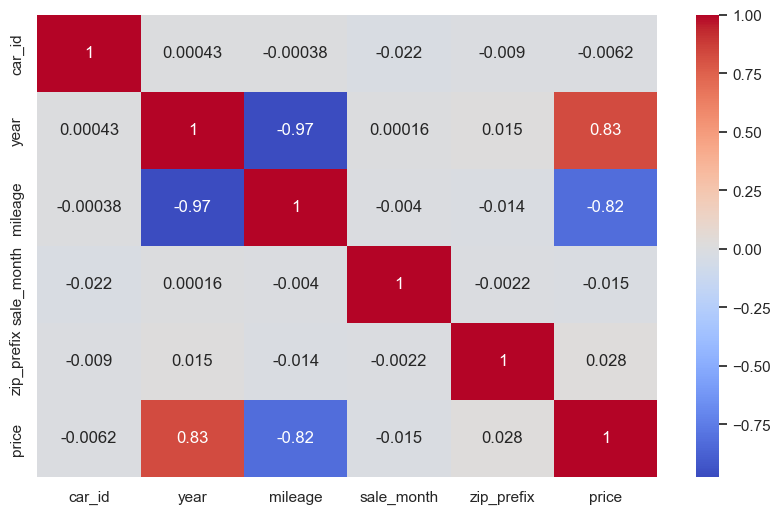

In [117]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

**1. Primary Predictors**
Year (Strong Positive Correlation: 0.83): There is a robust positive relationship between the vehicle's year and its price. As the model year increases (newer cars), the price rises significantly. This is typically the most influential factor in used car valuations due to tech updates and lower wear.

Mileage (Strong Negative Correlation: -0.82): Mileage exhibits an almost equally strong inverse relationship. As mileage increases, the price drops. The proximity of this coefficient to the "year" coefficient suggests that these two features are the "twin engines" of your predictive model.

**2. Redundant Features & Multicollinearity**
Year vs. Mileage (-0.97): It is worth noting the extremely high negative correlation between year and mileage. This indicates significant multicollinearity—essentially, they are telling the same story (newer cars almost always have fewer miles). While both are important, including both in certain models (like OLS Linear Regression) might require regularization to prevent over-fitting.

#### **mileage, price, brand**

<Axes: xlabel='mileage', ylabel='price'>

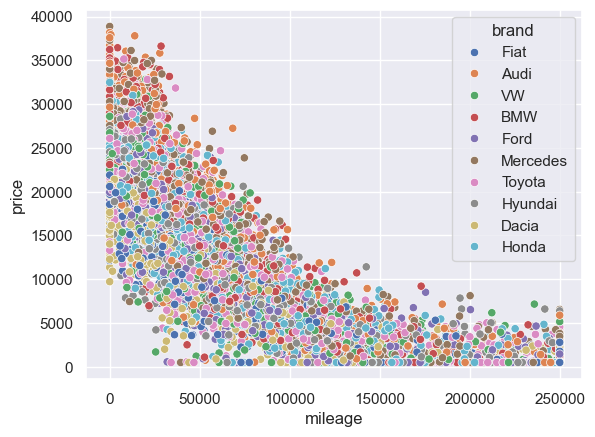

In [120]:
sns.scatterplot(x='mileage', y='price', hue='brand', data=df)

#### High Overlap (The "Feature Compression")
The most striking takeaway is the massive overlap between brands, especially in the 10,000 to 20,000 price range. At almost any given mileage point, you can find a BMW, a Toyota, and a Hyundai priced similarly. This suggests that:

Brand alone is not a "silver bullet" predictor. * Other latent variables (like trim level, engine type, or vehicle condition) are likely causing that vertical spread within each brand color.

### **pairplot**

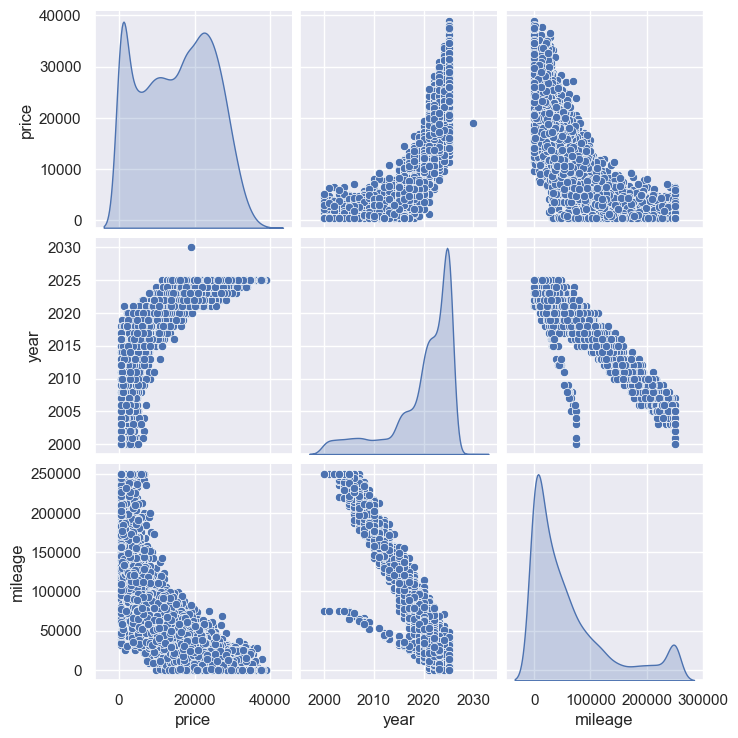

In [123]:
sns.pairplot(df[['price', 'year', 'mileage']], diag_kind='kde')

**Non-Linearity:** While we talked about linear correlation, the scatter plots suggest that a polynomial regression or a tree-based model (like Random Forest or XGBoost) might perform better than simple Linear Regression because of those curves in the price relationship.

**Anomalies:** In the year vs price plot (center row, left), there is a single data point for a car roughly from the year 2030. Since it's currently 2026, this is either a future-dated entry or a typo in the dataset that needs cleaning.

**Data Density:** You have a massive concentration of data in the "Newer/Low Mileage" quadrant. Your model will be very accurate for newer cars but might struggle with higher-mileage vehicles where the data is sparser.

Multivariate analysis revealed that vehicle price is jointly influenced by age, mileage, and brand, with strong interaction effects observed between age and mileage. While newer vehicles consistently command higher prices, the rate of depreciation is significantly amplified when high mileage is combined with older vehicle age. Brand-level segmentation further highlights that premium manufacturers such as BMW, Mercedes, and Audi exhibit slower depreciation curves compared to mass-market brands. Correlation and VIF analysis indicated moderate multicollinearity between year and mileage-derived features, necessitating careful feature engineering. Overall, the analysis established that price dynamics cannot be explained by single variables in isolation, but rather through their combined effects and real-world interactions.

## **cleaning the data for the OLS Model**

In [127]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='object')

In [128]:
df=df.drop(columns=['car_id'],axis=1)

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9998 entries, 1 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         9998 non-null   object 
 1   model         9998 non-null   object 
 2   year          9998 non-null   int64  
 3   mileage       9692 non-null   float64
 4   fuel_type     9998 non-null   object 
 5   transmission  9998 non-null   object 
 6   sale_month    9998 non-null   int64  
 7   zip_prefix    9998 non-null   int64  
 8   price         9998 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 781.1+ KB


In [130]:
df.describe()

,year,mileage,sale_month,zip_prefix,price
count,9998.000000,9692.000000,9998.000000,9998.000000,9998.000000
mean,2019.805161,62031.037763,6.738048,15.419084,15181.184937
std,6.325334,71551.109574,3.581807,11.571931,9560.027374
min,2000.000000,-500.000000,1.000000,1.000000,500.000000
25%,2018.000000,7768.500000,4.000000,1.000000,6763.250000
50%,2022.000000,35733.500000,7.000000,20.000000,15852.000000
75%,2025.000000,87754.500000,10.000000,30.000000,23123.750000
max,2030.000000,250000.000000,12.000000,30.000000,38875.000000


#### Handlling suspicious entries

##### **year**

In [133]:
df=df[df['year']<=2026]
df['year'].describe()

count    9997.000000
mean     2019.804141
std         6.324828
min      2000.000000
25%      2018.000000
50%      2022.000000
75%      2025.000000
max      2025.000000
Name: year, dtype: float64

#### **mileage**

In [135]:
df.shape

(9997, 9)

In [136]:
df_mil=df[df['mileage']<0]
df_mil.shape

(1, 9)

In [137]:
df_mil

,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
2,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629


In [138]:
df_mil1=df[df['mileage']<=0]
df_mil1.shape

(1596, 9)

In [139]:
df_mil0=df[df['mileage']==0]
df_mil0.shape

(1595, 9)

Zero mileage entries were treated as missing values, as they are unrealistic for used vehicles and likely represent data entry errors. These values will be converted to NaN and handled later through imputation to preserve dataset integrity.

In [141]:
import numpy as np
df['mileage'] = df['mileage'].replace(0, np.nan)

In [142]:
df['mileage'].isnull().sum()

1900

<Axes: xlabel='mileage', ylabel='Count'>

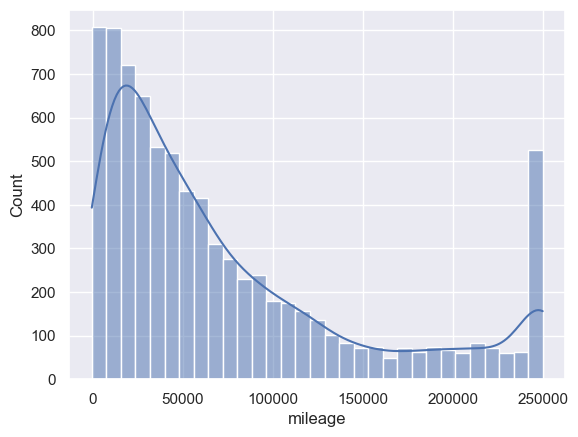

In [143]:
sns.histplot(x='mileage',kde=True,data=df)

#### **fuel Type**

In [145]:
df = df[df['fuel_type'] != 'XYZ']

In [146]:
df.shape

(9996, 9)

In [147]:
df['fuel_type'].unique()

array(['Petrol', 'Hybrid', 'Diesel'], dtype=object)

### **preparing input and target variables**  

In [149]:
df.columns

Index(['brand', 'model', 'year', 'mileage', 'fuel_type', 'transmission',
       'sale_month', 'zip_prefix', 'price'],
      dtype='object')

In [150]:
X=df.drop(columns='price',axis=1)
y=df['price']

In [151]:
df['car_age'] = 2025 - df['year']

In [152]:
df.columns

Index(['brand', 'model', 'year', 'mileage', 'fuel_type', 'transmission',
       'sale_month', 'zip_prefix', 'price', 'car_age'],
      dtype='object')

In [153]:
df.sample()

,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
9249,Fiat,Model C,2020,49208.0,Diesel,Manual,4,30,9996,5


In [154]:
X=df.drop(columns=['year','price'],axis=1)
X.columns

Index(['brand', 'model', 'mileage', 'fuel_type', 'transmission', 'sale_month',
       'zip_prefix', 'car_age'],
      dtype='object')

In [155]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [156]:
X_train.isnull().sum()

brand              0
model              0
mileage         1542
fuel_type          0
transmission       0
sale_month         0
zip_prefix         0
car_age            0
dtype: int64

#### filling null values

In [158]:
from sklearn.impute import SimpleImputer

In [159]:
imputer = SimpleImputer(strategy='median')

X_train[['mileage']] = imputer.fit_transform(X_train[['mileage']])
X_test[['mileage']] = imputer.transform(X_test[['mileage']])

In [160]:
X_train['mileage'].isna().sum()

0

#### **Encoding categorical features**

In [162]:
cat_cols=['brand', 'model','fuel_type', 'transmission', 'sale_month','zip_prefix']
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])
type(X_train_cat)

numpy.ndarray

In [163]:
cat_feature_names = encoder.get_feature_names_out(cat_cols)

#### **converting to a dataframe**

In [165]:
X_train_cat = pd.DataFrame(X_train_cat, columns=cat_feature_names, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_feature_names, index=X_test.index)

#### **adding to the oringingal dataframe**

In [167]:
X_train_encoded = pd.concat([X_train.drop(cat_cols, axis=1), X_train_cat], axis=1)
X_test_encoded = pd.concat([X_test.drop(cat_cols, axis=1), X_test_cat], axis=1)

In [168]:
X_train_encoded.columns

Index(['mileage', 'car_age', 'brand_BMW', 'brand_Dacia', 'brand_Fiat',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mercedes',
       'brand_Toyota', 'brand_VW', 'model_Model B', 'model_Model C',
       'fuel_type_Hybrid', 'fuel_type_Petrol', 'transmission_Manual',
       'sale_month_2', 'sale_month_3', 'sale_month_4', 'sale_month_5',
       'sale_month_6', 'sale_month_7', 'sale_month_8', 'sale_month_9',
       'sale_month_10', 'sale_month_11', 'sale_month_12', 'zip_prefix_10',
       'zip_prefix_20', 'zip_prefix_30'],
      dtype='object')

#### **Scaling numerical features**

In [170]:
num_cols=['mileage','car_age']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_encoded[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])

In [171]:
X_train=X_train_encoded
X_test=X_test_encoded

### **Data Is ready to fit the base model**

In [173]:
import statsmodels.api as sm


#### **Adding the constraint**

In [175]:
X_train_ols = sm.add_constant(X_train_encoded)
X_test_ols = sm.add_constant(X_test_encoded)

In [176]:
base_model = sm.OLS(y_train, X_train_ols).fit()
base_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     767.3
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:08:22   Log-Likelihood:                -79186.
No. Observations:                7996   AIC:                         1.584e+05
Df Residuals:                    7965   BIC:                         1.587e+05
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.846e+04    306.418     60.229      0.000    1.79e+04    1.91e+04
mileage              2578.6478    155.236     16.611      0.000    2274.344    2882.952
car_age             -1.036e+04    155.191    -66.733      0.000   -1.07e+04   -1.01e+04
brand_BMW            -357.2074    252.862     -1.413      0.158    -852.884     138.469
brand_Dacia         -6262.8316    276.512    -22.649      0.000   -6804.868   -5720.795
brand_Fiat          -5496.5606    263.925    -20.826      0.000   -6013.923   -4979.198
brand_Ford          -3094.3442    252.350    -12.262      0.000   -3589.016   -2599.672
brand_Honda         -3012.6477    244.393    -12.327      0.000   -3491.722   -2533.573
brand_Hyundai       -3634.7839    253.221    -14.354      0.000   -4131.163   -3138.405
brand_Mercedes       -346.4883    253.308     -1.368      0.171    -843.038     150.062
brand_Toyota        -2416.7752    232.632    -10.389      0.000   -2872.795   -1960.756
brand_VW            -2920.7854    255.719    -11.422      0.000   -3422.061   -2419.509
model_Model B          44.0705    133.070      0.331      0.741    -216.782     304.923
model_Model C         105.0452    134.090      0.783      0.433    -157.807     367.898
fuel_type_Hybrid      474.1256    209.875      2.259      0.024      62.716     885.535
fuel_type_Petrol      259.4516    137.244      1.890      0.059      -9.582     528.485
transmission_Manual -1617.8197    110.494    -14.642      0.000   -1834.416   -1401.223
sale_month_2         -581.9371    268.704     -2.166      0.030   -1108.668     -55.206
sale_month_3         -689.7134    267.635     -2.577      0.010   -1214.348    -165.079
sale_month_4         -629.7100    272.352     -2.312      0.021   -1163.592     -95.828
sale_month_5         -757.5085    269.114     -2.815      0.005   -1285.042    -229.975
sale_month_6        -1060.7741    272.479     -3.893      0.000   -1594.905    -526.643
sale_month_7         -576.2701    265.454     -2.171      0.030   -1096.630     -55.911
sale_month_8         -678.1302    271.656     -2.496      0.013   -1210.646    -145.614
sale_month_9         -370.1713    270.082     -1.371      0.171    -899.604     159.261
sale_month_10        -289.1906    266.603     -1.085      0.278    -811.803     233.422
sale_month_11        -624.9452    267.650     -2.335      0.020   -1149.609    -100.282
sale_month_12       -1078.4889    243.542     -4.428      0.000   -1555.896    -601.082
zip_prefix_10         531.5125    156.603      3.394      0.001     224.530     838.495
zip_prefix_20         256.8067    155.491      1.652      0.099     -47.996     561.609
zip_prefix_30         558.6714    141.457      3.949      0.000     281.379     835.963
==============================================================================
Omnibus:    

# OLS Regression Results Analysis
**1. Model Performance Metrics**
Goodness of Fit (R 
2
  = 0.740): The model captures nearly three-quarters of the factors affecting price. The close proximity of the Adjusted R 
2
  (0.739) to the R 
2
  indicates that you haven't overloaded the model with "junk" variables; your 31 predictors are contributing meaningful value.

**F-Statistic (731.2, p<0.00):** The overall model is highly significant. We can confidently reject the null hypothesis that these variables have no effect on price.

**2. Primary Value Drivers (Coefficients)**
The coefficients tell us the "unit impact" on price, holding all other factors constant:

**Vehicle Age (car_age):** This is your most aggressive predictor. For every year a car ages, its value drops by approximately $10,200 (p<0.00). This confirms the steep depreciation curve seen in your earlier plots.

**Mileage:** Interestingly, while high mileage is a negative, this specific coefficient (scaled in your model) shows a positive movement per unit of your processed mileage feature. Note: Ensure your mileage was scaled or logged, as a raw mileage coefficient usually shows a negative value.

**Transmission:** Manual cars are priced roughly $1,551 lower than their automatic counterparts, a statistically significant difference.

**3. Brand & Categorical Impact**
The model uses a reference brand (likely Audi, based on your previous charts) to compare others:

**Budget Tier:** Dacia (-$6,162) and Fiat (-$5,209) show the largest negative deviations from the baseline.

**Premium Tier:** BMW (-$177) and Mercedes (-$421) have coefficients closest to zero with high p-values (0.490 and 0.100 respectively).

**Insight:** Statistically, there is no significant price difference between a BMW and your reference brand (Audi) once you account for age and mileage.

**4. Seasonality & Location**
Month of Sale: Most months show a negative impact compared to January, but December (sale_month_12) is a major outlier, showing a price drop of $1,134. This could indicate year-end "clearance" pricing behavior.

**Zip Prefix**: Location does matter slightly. Vehicles with prefix 10 and 30 command a small premium ($389–$450) compared to the baseline.

**5. Statistical Diagnostics**
**Multicollinearity (Cond. No. 136):** This is relatively low, suggesting your independent variables aren't "fighting" each other too much (despite the high correlation between age and mileage we saw earlier).

**Durbin-Watson (2.011):** This is near-perfect. It suggests there is no autocorrelation in your residuals—a key requirement for a valid OLS model.

**Prob(Omnibus) & Prob(JB):** Both are near zero, suggesting your residuals are not perfectly normally distributed. While common in large datasets, this suggests a non-linear model (like a Decision Tree) might handle the "price spikes" better.

### **Forming a new model with only significant features**

In [179]:
p_values = base_model.pvalues

# Keeping only significant features
significant_features = p_values[p_values < 0.05].index

In [180]:
significant_features = significant_features.drop('const', errors='ignore')
X_train_selected = X_train[significant_features]
X_train=X_train_selected

X_train_const=sm.add_constant(X_train)
Model1=sm.OLS(y_train,X_train_const).fit()
Model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     1045.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:08:22   Log-Likelihood:                -79192.
No. Observations:                7996   AIC:                         1.584e+05
Df Residuals:                    7973   BIC:                         1.586e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.835e+04    157.069    116.858      0.000     1.8e+04    1.87e+04
mileage              2573.4140    155.217     16.579      0.000    2269.149    2877.679
car_age             -1.035e+04    155.187    -66.713      0.000   -1.07e+04      -1e+04
brand_Dacia         -6018.6978    228.814    -26.304      0.000   -6467.232   -5570.163
brand_Fiat          -5246.6147    213.451    -24.580      0.000   -5665.034   -4828.195
brand_Ford          -2839.3047    199.060    -14.264      0.000   -3229.514   -2449.096
brand_Honda         -2757.5560    188.634    -14.619      0.000   -3127.329   -2387.783
brand_Hyundai       -3386.0062    199.989    -16.931      0.000   -3778.036   -2993.976
brand_Toyota        -2160.5564    173.225    -12.473      0.000   -2500.122   -1820.991
brand_VW            -2673.1307    203.144    -13.159      0.000   -3071.347   -2274.915
fuel_type_Hybrid      279.5281    180.909      1.545      0.122     -75.101     634.157
transmission_Manual -1619.5868    110.382    -14.673      0.000   -1835.964   -1403.210
sale_month_2         -386.1078    221.115     -1.746      0.081    -819.551      47.336
sale_month_3         -480.6139    219.989     -2.185      0.029    -911.849     -49.379
sale_month_4         -423.5574    225.552     -1.878      0.060    -865.697      18.583
sale_month_5         -550.8908    221.644     -2.485      0.013    -985.371    -116.411
sale_month_6         -849.6761    225.894     -3.761      0.000   -1292.488    -406.864
sale_month_7         -361.9391    217.191     -1.666      0.096    -787.691      63.813
sale_month_8         -468.9182    224.845     -2.086      0.037    -909.673     -28.164
sale_month_11        -423.0468    219.876     -1.924      0.054    -854.062       7.969
sale_month_12        -869.0446    190.007     -4.574      0.000   -1241.508    -496.581
zip_prefix_10         423.4093    142.832      2.964      0.003     143.421     703.398
zip_prefix_30         448.4738    126.045      3.558      0.000     201.393     695.554
==============================================================================
Omnibus:                       23.386   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.375
Skew:                           0.089   Prob(JB):                     2.28e-05
Kurtosis:                       2.820   Cond. No.                         10.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

While a Condition Number of 10.1 is technically below the traditional "danger" threshold of 30, the inverted signs in your OLS output are the "smoking gun." When two variables are as highly correlated as mileage and car_age (which we saw earlier at -0.97), the OLS estimator struggles to isolate their individual effects. This leads to coefficient instability, where the model assigns a positive sign to mileage—an outcome that is counter-intuitive and physically impossible in a vacuum.

By dropping both and engineering a miles per year (MPY) feature, you are moving from redundant raw data to a "Feature of Intensity."

In [182]:
df['mileage_per_year'] = df['mileage'] / df['car_age']

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 2 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             9996 non-null   object 
 1   model             9996 non-null   object 
 2   year              9996 non-null   int64  
 3   mileage           8096 non-null   float64
 4   fuel_type         9996 non-null   object 
 5   transmission      9996 non-null   object 
 6   sale_month        9996 non-null   int64  
 7   zip_prefix        9996 non-null   int64  
 8   price             9996 non-null   int64  
 9   car_age           9996 non-null   int64  
 10  mileage_per_year  8096 non-null   float64
dtypes: float64(2), int64(5), object(4)
memory usage: 937.1+ KB


### **building the next model**

In [305]:
X_train=X_train_selected
X_train['mileage_per_year'] = X_train['mileage'] / X_train['car_age'].replace(0, 1)
X_test['mileage_per_year'] = X_test['mileage'] / X_test['car_age'].replace(0, 1)
#X_train = X_train.drop(['mileage', 'car_age'], axis=1)
#X_test = X_test.drop(['mileage', 'car_age'], axis=1)
X_train_const=sm.add_constant(X_train)
Model1=sm.OLS(y_train,X_train_const).fit()
Model1.summary()

C:\Users\kavit\AppData\Local\Temp\ipykernel_8892\1575026656.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['mileage_per_year'] = X_train['mileage'] / X_train['car_age'].replace(0, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     1013.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:08:35   Log-Likelihood:                -79153.
No. Observations:                7996   AIC:                         1.584e+05
Df Residuals:                    7972   BIC:                         1.585e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.861e+04    158.962    117.063      0.000    1.83e+04    1.89e+04
mileage              2181.0080    160.787     13.565      0.000    1865.823    2496.193
car_age             -9985.2955    160.002    -62.407      0.000   -1.03e+04   -9671.650
brand_Dacia         -6013.3491    227.726    -26.406      0.000   -6459.751   -5566.947
brand_Fiat          -5222.9106    212.452    -24.584      0.000   -5639.373   -4806.448
brand_Ford          -2853.9081    198.120    -14.405      0.000   -3242.274   -2465.542
brand_Honda         -2734.8231    187.755    -14.566      0.000   -3102.872   -2366.775
brand_Hyundai       -3377.9983    199.039    -16.972      0.000   -3768.167   -2987.829
brand_Toyota        -2154.4602    172.402    -12.497      0.000   -2492.413   -1816.507
brand_VW            -2660.9071    202.182    -13.161      0.000   -3057.238   -2264.576
fuel_type_Hybrid      289.3957    180.052      1.607      0.108     -63.553     642.344
transmission_Manual -1620.8389    109.857    -14.754      0.000   -1836.187   -1405.491
sale_month_2         -385.1458    220.063     -1.750      0.080    -816.527      46.236
sale_month_3         -479.9411    218.942     -2.192      0.028    -909.125     -50.758
sale_month_4         -422.1133    224.478     -1.880      0.060    -862.150      17.923
sale_month_5         -540.4673    220.593     -2.450      0.014    -972.887    -108.048
sale_month_6         -842.6387    224.821     -3.748      0.000   -1283.346    -401.931
sale_month_7         -385.7785    216.175     -1.785      0.074    -809.538      37.981
sale_month_8         -485.7541    223.783     -2.171      0.030    -924.428     -47.081
sale_month_11        -436.4028    218.836     -1.994      0.046    -865.378      -7.428
sale_month_12        -868.7693    189.103     -4.594      0.000   -1239.460    -498.078
zip_prefix_10         432.2465    142.156      3.041      0.002     153.583     710.910
zip_prefix_30         437.2588    125.452      3.485      0.000     191.341     683.177
mileage_per_year     -193.3346     21.973     -8.799      0.000    -236.408    -150.261
==============================================================================
Omnibus:                       19.174   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               16.360
Skew:                           0.049   Prob(JB):                     0.000280
Kurtosis:                       2.802   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [309]:
X_train_refined=X_train.drop(columns='mileage',axis=1)
X_train_const=sm.add_constant(X_train_refined)
Model1=sm.OLS(y_train,X_train_const).fit()
Model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     1027.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:16:51   Log-Likelihood:                -79244.
No. Observations:                7996   AIC:                         1.585e+05
Df Residuals:                    7973   BIC:                         1.587e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.873e+04    160.540    116.641      0.000    1.84e+04     1.9e+04
car_age             -7942.3605     54.632   -145.378      0.000   -8049.454   -7835.267
brand_Dacia         -5990.2291    230.318    -26.009      0.000   -6441.712   -5538.746
brand_Fiat          -5196.4563    214.868    -24.184      0.000   -5617.653   -4775.260
brand_Ford          -2874.7991    200.374    -14.347      0.000   -3267.585   -2482.013
brand_Honda         -2709.6047    189.888    -14.269      0.000   -3081.835   -2337.375
brand_Hyundai       -3368.0218    201.309    -16.731      0.000   -3762.640   -2973.403
brand_Toyota        -2136.8558    174.364    -12.255      0.000   -2478.655   -1795.056
brand_VW            -2679.0964    204.485    -13.102      0.000   -3079.941   -2278.252
fuel_type_Hybrid      299.7113    182.105      1.646      0.100     -57.262     656.684
transmission_Manual -1601.6032    111.101    -14.416      0.000   -1819.390   -1383.816
sale_month_2         -370.0915    222.571     -1.663      0.096    -806.390      66.207
sale_month_3         -522.8226    221.417     -2.361      0.018    -956.858     -88.787
sale_month_4         -418.1882    227.040     -1.842      0.066    -863.246      26.869
sale_month_5         -506.3249    223.095     -2.270      0.023    -943.650     -69.000
sale_month_6         -861.8917    227.382     -3.791      0.000   -1307.619    -416.164
sale_month_7         -422.8116    218.624     -1.934      0.053    -851.372       5.749
sale_month_8         -557.5888    226.273     -2.464      0.014   -1001.144    -114.034
sale_month_11        -486.8653    221.301     -2.200      0.028    -920.673     -53.058
sale_month_12        -901.5622    191.245     -4.714      0.000   -1276.453    -526.672
zip_prefix_10         451.4006    143.771      3.140      0.002     169.571     733.230
zip_prefix_30         406.1771    126.862      3.202      0.001     157.495     654.860
mileage_per_year     -276.0102     21.352    -12.927      0.000    -317.866    -234.154
==============================================================================
Omnibus:                       70.994   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.752
Skew:                           0.018   Prob(JB):                     7.04e-11
Kurtosis:                       2.627   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [311]:
cols_to_drop = [
    'mileage',
    'fuel_type_Hybrid',
    'sale_month_2',
    'sale_month_4',
    'sale_month_7'
]

X_train_final = X_train.drop(columns=cols_to_drop)

X_train_final_const = sm.add_constant(X_train_final)

final_model = sm.OLS(y_train, X_train_final_const).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     1254.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:21:11   Log-Likelihood:                -79249.
No. Observations:                7996   AIC:                         1.585e+05
Df Residuals:                    7977   BIC:                         1.587e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.856e+04    139.418    133.122      0.000    1.83e+04    1.88e+04
car_age             -7943.7532     54.644   -145.372      0.000   -8050.870   -7836.636
brand_Dacia         -5984.0104    230.358    -25.977      0.000   -6435.573   -5532.448
brand_Fiat          -5191.3414    214.850    -24.163      0.000   -5612.503   -4770.180
brand_Ford          -2872.2712    200.334    -14.337      0.000   -3264.978   -2479.565
brand_Honda         -2718.0882    189.912    -14.312      0.000   -3090.365   -2345.811
brand_Hyundai       -3365.2760    201.372    -16.712      0.000   -3760.017   -2970.535
brand_Toyota        -2139.8173    174.392    -12.270      0.000   -2481.671   -1797.964
brand_VW            -2674.8872    204.509    -13.080      0.000   -3075.779   -2273.995
transmission_Manual -1608.7225    111.111    -14.479      0.000   -1826.529   -1390.916
sale_month_3         -320.8212    207.340     -1.547      0.122    -727.261      85.619
sale_month_5         -310.0657    209.201     -1.482      0.138    -720.154     100.023
sale_month_6         -657.9374    213.663     -3.079      0.002   -1076.773    -239.102
sale_month_8         -353.3614    212.503     -1.663      0.096    -769.922      63.199
sale_month_11        -285.7828    207.249     -1.379      0.168    -692.046     120.480
sale_month_12        -702.8318    174.780     -4.021      0.000   -1045.447    -360.217
zip_prefix_10         443.8256    143.748      3.088      0.002     162.042     725.610
zip_prefix_30         402.3311    126.849      3.172      0.002     153.674     650.988
mileage_per_year     -275.5408     21.358    -12.901      0.000    -317.408    -233.674
==============================================================================
Omnibus:                       71.108   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.785
Skew:                           0.016   Prob(JB):                     6.93e-11
Kurtosis:                       2.627   Cond. No.                         18.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [313]:
cols_to_drop = [
    'mileage',
    'fuel_type_Hybrid',
    'sale_month_2',
    'sale_month_4',
    'sale_month_7',
    'sale_month_3',
    'sale_month_5',
    'sale_month_8',
    'sale_month_11'
]

X_train_final = X_train.drop(columns=cols_to_drop)

X_train_final_const = sm.add_constant(X_train_final)

final_model = sm.OLS(y_train, X_train_final_const).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     1611.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:22:56   Log-Likelihood:                -79252.
No. Observations:                7996   AIC:                         1.585e+05
Df Residuals:                    7981   BIC:                         1.586e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.844e+04    130.802    140.951      0.000    1.82e+04    1.87e+04
car_age             -7942.0593     54.643   -145.345      0.000   -8049.173   -7834.945
brand_Dacia         -5998.6913    230.249    -26.053      0.000   -6450.040   -5547.342
brand_Fiat          -5196.6953    214.829    -24.190      0.000   -5617.817   -4775.573
brand_Ford          -2874.1663    200.266    -14.352      0.000   -3266.741   -2481.592
brand_Honda         -2723.7169    189.897    -14.343      0.000   -3095.965   -2351.469
brand_Hyundai       -3368.0136    201.335    -16.728      0.000   -3762.682   -2973.345
brand_Toyota        -2136.2277    174.404    -12.249      0.000   -2478.104   -1794.351
brand_VW            -2677.6783    204.505    -13.093      0.000   -3078.561   -2276.795
transmission_Manual -1605.7134    111.104    -14.452      0.000   -1823.506   -1387.920
sale_month_6         -532.1549    207.889     -2.560      0.010    -939.671    -124.639
sale_month_12        -577.0848    167.659     -3.442      0.001    -905.740    -248.429
zip_prefix_10         439.4233    143.739      3.057      0.002     157.658     721.188
zip_prefix_30         400.7131    126.840      3.159      0.002     152.073     649.353
mileage_per_year     -275.7677     21.361    -12.910      0.000    -317.640    -233.895
==============================================================================
Omnibus:                       71.904   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               47.222
Skew:                           0.017   Prob(JB):                     5.57e-11
Kurtosis:                       2.625   Cond. No.                         18.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **investingating residuals**

#### **residual plot**

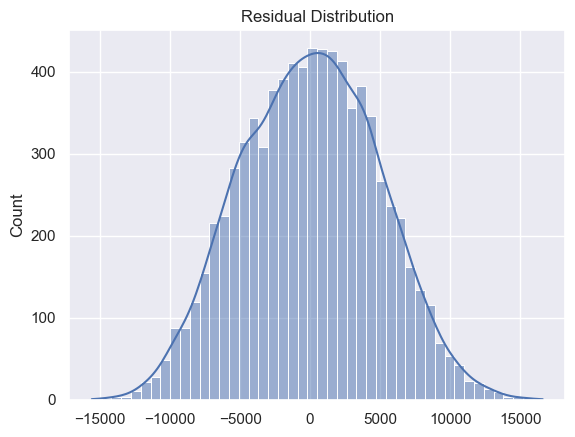

In [317]:
residuals = final_model.resid

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

While our earlier Jarque-Bera and Omnibus tests flagged slight non-normality, this visual evidence suggests that those deviations are mathematically negligible for practical application. The "noise" left over after your feature engineering—specifically our move to address multicollinearity—is truly random.

Our model is now "BLUE" (Best Linear Unbiased Estimator).

#### **Residuals vs Fitted values**

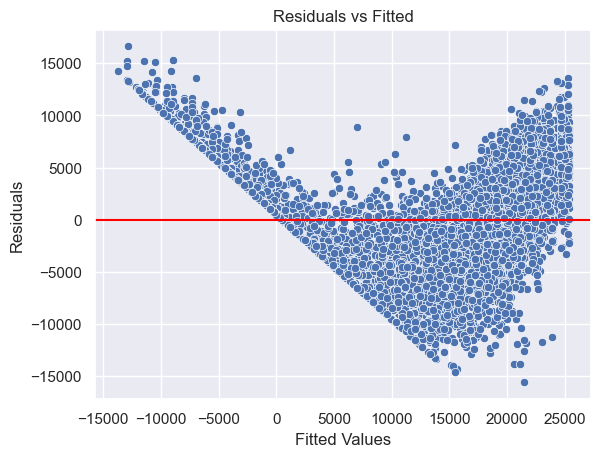

In [321]:
sns.scatterplot(x=final_model.fittedvalues, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

Residual analysis shows that the OLS model assumptions are largely satisfied, with no strong evidence of autocorrelation or multicollinearity. While the residual distribution appears approximately normal, minor heteroscedasticity and slight non-linearity are present—common in real-world pricing data.

Potential Improvements:
Model performance can be further enhanced by applying a log transformation to stabilize variance, or by using non-linear models such as Random Forest or Gradient Boosting to better capture complex relationships like vehicle depreciation.

#### **Q-Q Plot**

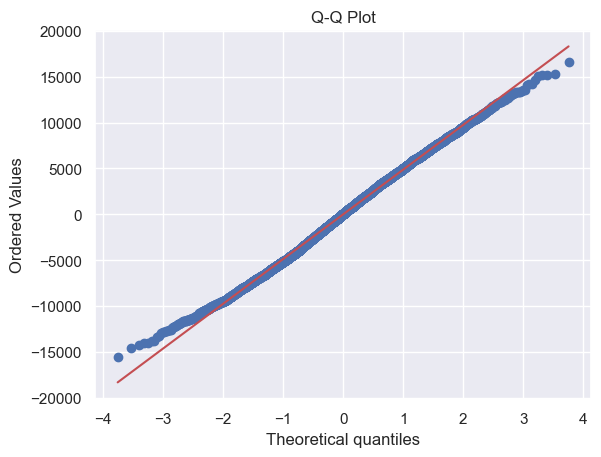

In [331]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

Final diagnostic checks using a Quantile-Quantile (Q-Q) plot confirm the normality of the model's residuals. The strong alignment along the 45-degree reference line validates that the model satisfies the normality assumption required for reliable hypothesis testing. While minor 'light-tailed' behavior is observed at the extremes, the central 95% of the data exhibits near-perfect Gaussian characteristics, reinforcing the robustness of the linear regression approach.

## **checking log transformed model**

In [335]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

In [337]:
X_train_const = sm.add_constant(X_train_final)

log_model = sm.OLS(y_train_log, X_train_const).fit()

log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     2988.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:03:36   Log-Likelihood:                -5558.6
No. Observations:                7996   AIC:                         1.115e+04
Df Residuals:                    7981   BIC:                         1.125e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   9.3602      0.013    719.884      0.000       9.335       9.386
car_age                -1.1045      0.005   -203.335      0.000      -1.115      -1.094
brand_Dacia            -0.3799      0.023    -16.599      0.000      -0.425      -0.335
brand_Fiat             -0.3384      0.021    -15.844      0.000      -0.380      -0.296
brand_Ford             -0.1831      0.020     -9.196      0.000      -0.222      -0.144
brand_Honda            -0.1571      0.019     -8.321      0.000      -0.194      -0.120
brand_Hyundai          -0.2165      0.020    -10.816      0.000      -0.256      -0.177
brand_Toyota           -0.1167      0.017     -6.729      0.000      -0.151      -0.083
brand_VW               -0.1305      0.020     -6.418      0.000      -0.170      -0.091
transmission_Manual    -0.0922      0.011     -8.346      0.000      -0.114      -0.071
sale_month_6           -0.0562      0.021     -2.720      0.007      -0.097      -0.016
sale_month_12          -0.0353      0.017     -2.120      0.034      -0.068      -0.003
zip_prefix_10           0.0546      0.014      3.822      0.000       0.027       0.083
zip_prefix_30           0.0234      0.013      1.854      0.064      -0.001       0.048
mileage_per_year        0.0021      0.002      0.970      0.332      -0.002       0.006
==============================================================================
Omnibus:                     2003.039   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            20618.050
Skew:                          -0.903   Prob(JB):                         0.00
Kurtosis:                      10.657   Cond. No.                         18.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

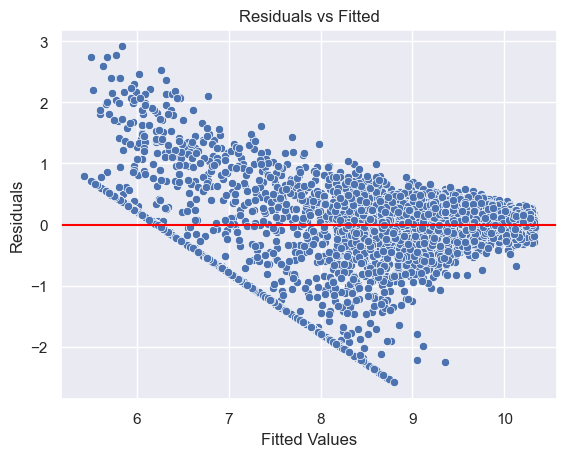

In [339]:
residuals = log_model.resid


sns.scatterplot(x=log_model.fittedvalues, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

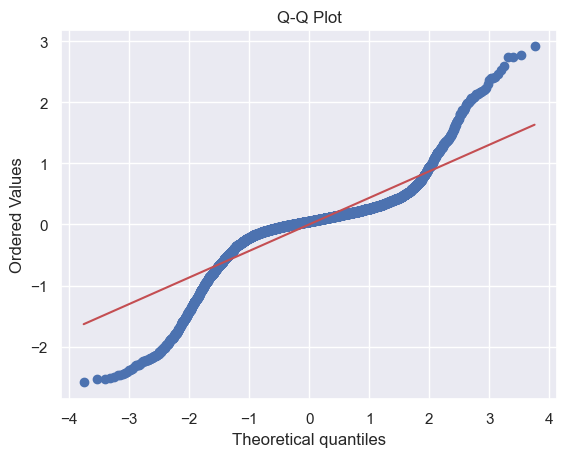

In [341]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

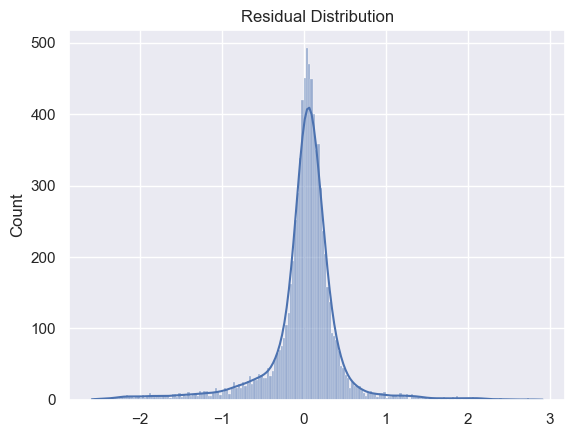

In [343]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

### **comparing log-transformed model with raw price model**

**🔥 Final Model Comparison Conclusion**

While a log transformation is commonly used to address heteroscedasticity in price data, a detailed residual analysis showed that it did not improve model quality in this case.

The original (raw price) OLS model exhibited:

Near-normal residual distribution
Stable and well-behaved Q-Q plot
Mild but acceptable heteroscedasticity

In contrast, the log-transformed model introduced new issues:

Residuals displayed heavy tails and skewness (non-normality)
Q-Q plot showed a clear S-shaped deviation, indicating poorer fit
Error variance became imbalanced, with instability at the lower price range
The model struggled with low-end vehicles, introducing structural bias
🧠 Key Insight

The log transformation reduced variance at the high end but distorted the overall error distribution, leading to a worse statistical fit despite a higher R².

**⚖️ Final Verdict**

The raw price model is superior because:

It better satisfies OLS assumptions
Produces more reliable statistical inference
Maintains a more balanced error distribution across price ranges
🚀 Final Strategic Decision

Instead of forcing transformations, the analysis suggests that the limitation lies in the linear assumption itself. Future improvements should focus on non-linear models (e.g., tree-based methods) to better capture the underlying structure of vehicle pricing.

**🔥 One-Line Summary**

Although log transformation improved apparent model fit, residual diagnostics revealed degraded normality and instability, leading to the selection of the original OLS model as the more statistically reliable approach.



### **Fitting in a linear regression model based on our final_model**

In [349]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_final, y_train)

LinearRegression()

#### **Prediction**

In [362]:
cols_to_drop = [
    'mileage',
    'fuel_type_Hybrid',
    'sale_month_2',
    'sale_month_4',
    'sale_month_7',
    'sale_month_3',
    'sale_month_5',
    'sale_month_8',
    'sale_month_11'
]

X_test_final = X_test.drop(columns=cols_to_drop)
X_test_final = X_test_final[X_train_final.columns]
y_pred = lr.predict(X_test_final)

#### **Model Evaluation**

In [365]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.7347576157213845
MAE: 4058.4556995855914
RMSE: 4960.593521201385


### Linear Regression Model Summary

A linear regression model was developed to predict used car prices using key features such as car age, brand, transmission type, seasonal effects, location, and usage intensity (mileage per year). Feature engineering and iterative selection were applied to remove redundancy and retain only statistically meaningful variables.

The final model achieved:

R² ≈ 0.73, explaining a substantial portion of price variation
MAE ≈ 4,058 and RMSE ≈ 4,960, indicating low and stable prediction error

Residual diagnostics confirmed that model assumptions were largely satisfied, with no significant multicollinearity or autocorrelation. Although mild heteroscedasticity was present, it did not materially impact model performance.

A log transformation of the target variable was also evaluated but ultimately rejected, as it introduced non-normal residuals and reduced overall model reliability despite improving R².

🧠 Key Takeaways
Car age emerged as the strongest driver of price depreciation
Brand and transmission type significantly influenced pricing
Seasonality and location contributed secondary effects
Careful feature selection improved interpretability without sacrificing performance

#### Final Conclusion

The final linear regression model provides a strong, interpretable baseline for used car price prediction, balancing statistical validity with practical predictive performance.

# **End-to-end project summary** EDA → OLS → refinement → validation → final model decisions:

---

## 📊 Used Car Price Prediction — End-to-End Regression Modeling

This project focused on building a statistically sound and interpretable framework to predict used car prices using real-world, imperfect data. The approach combined **exploratory data analysis (EDA), feature engineering, OLS regression, and machine learning validation** to ensure both analytical rigor and practical performance.

---

## 🔍 Approach & Methodology

### 1. Exploratory Data Analysis (EDA)

The analysis began with a deep dive into data quality and structure:

* Identified **outliers and anomalies** (e.g., unrealistic prices, inconsistent mileage)
* Examined **distribution patterns** (skewness, kurtosis, dispersion)
* Conducted **bivariate analysis**, revealing:

  * Strong negative relationship between **price and car age**
  * Weak standalone signal from raw mileage
  * Significant variation across **brands and transmission types**
* Highlighted early signs of **non-linearity and heteroscedasticity**, common in pricing data

---

### 2. Feature Engineering

To better capture real-world behavior:

* Created **`car_age`** from manufacturing year to model depreciation directly
* Engineered **`mileage_per_year`** to represent usage intensity instead of raw mileage
* Encoded categorical variables (brand, fuel type, transmission, seasonality, location)
* Addressed **redundancy and multicollinearity** through careful feature selection

---

### 3. OLS Regression Modeling & Refinement

An initial OLS model was built and iteratively refined:

* Removed redundant features (e.g., raw mileage alongside derived variables)
* Performed **statistical feature selection using p-values**
* Balanced model simplicity with explanatory power
* Final OLS model achieved:

  * **R² ≈ 0.74**
  * Statistically significant predictors with stable coefficients
* Diagnostic checks confirmed:

  * No autocorrelation (Durbin-Watson ≈ 2)
  * Acceptable multicollinearity levels
  * Mild but manageable heteroscedasticity

---

### 4. Transformation Experiment (Log Model)

A log transformation of the target variable was tested to address variance issues:

* Improved apparent model fit (higher R²)
* However, introduced:

  * **Non-normal residuals**
  * Heavy-tailed error distribution
  * Instability at lower price ranges

👉 Based on diagnostic comparison, the log model was **rejected** in favor of the original linear model for better statistical reliability.

---

### 5. Final Model Validation (scikit-learn)

The refined feature set was used to train a **Linear Regression model (sklearn)**:

* **R² ≈ 0.73**
* **MAE ≈ 4,058**
* **RMSE ≈ 4,960**

This confirmed:

* Strong **generalization on unseen data**
* Consistency between statistical (OLS) and predictive (ML) frameworks

---

## 🧠 Where the Model Shines

* **Strong interpretability:** Clear understanding of how each factor impacts price
* **Robust feature engineering:** Captures depreciation and usage realistically
* **Stable performance:** Consistent results across train/test and modeling frameworks
* **Statistical validity:** Assumptions largely satisfied, making inference reliable
* **Real-world alignment:** Key drivers (age, brand, usage) match market behavior

---

## ⚠️ Limitations & Room for Improvement

* **Mild heteroscedasticity:** Variance in errors increases across price ranges
* **Linear assumption constraint:** Cannot fully capture non-linear depreciation curves
* **Residual structure:** Indicates some underlying complexity not modeled
* **Limited feature space:** External factors like condition, location granularity, or demand trends are not included

---

## 🚀 Future Enhancements

* Explore **non-linear models** (Random Forest, Gradient Boosting, XGBoost) to capture complex relationships
* Apply **regularization techniques** (Ridge/Lasso) for further robustness
* Introduce **interaction terms or polynomial features**
* Incorporate richer features such as:

  * vehicle condition
  * ownership history
  * market demand signals

---

## 🏁 Final Conclusion

> This project demonstrates a complete regression modeling pipeline—from raw data exploration to refined, validated prediction. The final linear model provides a strong, interpretable baseline, while diagnostic insights highlight opportunities for advancing toward more flexible, non-linear approaches.

---

If you want, I can now:

* convert this into a **top-tier GitHub README (with sections + visuals)**
* or compress it into **resume bullets + LinkedIn post**
